## 🚀 Glider Data Cleaning
This section handles the merging, formatting, and preparation of the glider dataset.  
Includes: depth categorization, zone labeling, low oxygen flag, and daily sampling

The final Data Frame is called (Glider_sampled_df)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import glob


from sklearn.utils import resample
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm




#Find all the glider csv files
glider_csv_files = glob.glob("data/Glider data/*.csv")

# Read and merge
df_list = [pd.read_csv(file) for file in glider_csv_files]
Glider_df = pd.concat(df_list, ignore_index=True)

# Optional: save to CSV
# Glider_df.to_csv("Glider_data.csv", index=False)


In [2]:
#Convert Timestamp to Date
Glider_df['time'] = pd.to_datetime(Glider_df['time'])
Glider_df['date'] = Glider_df['time'].dt.strftime('%Y/%m/%d')

In [3]:
#Find the min and max depth
Glider_df['depth'].describe()

count    9.549632e+06
mean     1.224928e+02
std      1.016018e+02
min     -1.784959e-01
25%      3.603288e+01
50%      8.665289e+01
75%      2.025048e+02
max      3.574836e+02
Name: depth, dtype: float64

In [4]:
#Classify all entries by depth (Upper, Mid, Deep)
def classify_depth(depth):
    if depth <= 50:
        return 'Upper'
    elif depth <= 200:
        return 'Mid'
    else:
        return 'Deep'

#Add the depth_category column
Glider_df['depth_category'] = Glider_df['depth'].apply(classify_depth)

# Confirm the new column was added correctly
# Glider_df[['depth', 'depth_category']].head()

In [5]:
#Find the range for both LATITUDE & LONGITUDE
lat_min = Glider_df['latitude'].min()
lat_max = Glider_df['latitude'].max()
lon_min = Glider_df['longitude'].min()
lon_max = Glider_df['longitude'].max()

print(f"Latitude range: {lat_min:.4f}° to {lat_max:.4f}°")
print(f"Longitude range: {lon_min:.4f}° to {lon_max:.4f}°")
print("\nThis means the glider data covers ~250 km north–south and ~400 km east–west.")
print("To match the original case study methodology, we divided the region into ~0.5° grid zones")
print("(approximately ~55 km in latitude × ~40–45 km in longitude at this location).")

Latitude range: 47.0294° to 49.2671°
Longitude range: -64.4084° to -59.6130°

This means the glider data covers ~250 km north–south and ~400 km east–west.
To match the original case study methodology, we divided the region into ~0.5° grid zones
(approximately ~55 km in latitude × ~40–45 km in longitude at this location).


In [6]:
#Add the zone column to the Data Frame
Glider_df['zone'] = (
    (Glider_df['latitude'] // 0.5).astype(int).astype(str) + "_" +
    (Glider_df['longitude'] // 0.5).astype(int).astype(str)
)

# Count total number of Zones (There are 26 in total)
# Glider_df['zone'].nunique()

# #Display the actual zones
Glider_df['zone'].unique()

array(['94_-128', '94_-127', '95_-127', '95_-128', '95_-129', '96_-128',
       '96_-127', '96_-123', '96_-124', '97_-124', '97_-125', '97_-126',
       '96_-125', '97_-127', '97_-128', '97_-129', '98_-129', '98_-128',
       '98_-127', '94_-121', '95_-121', '95_-122', '96_-122', '94_-129',
       '94_-122', '95_-120'], dtype=object)

In [7]:
# Sort zones by numeric latitude and longitude (not alphabetically)
zone_tuples = [tuple(map(int, z.split('_'))) for z in Glider_df['zone'].unique()]
sorted_zones = sorted(zone_tuples)
sorted_zone_strings = [f"{lat}_{lon}" for lat, lon in sorted_zones]

# Create mapping: zone strings (e.g. "94_-128") → zone labels ("zone1", "zone2", ...)
# Zones are ordered numerically from southwest to northeast
zone_mapping = {zone: f"zone{i+1}" for i, zone in enumerate(sorted_zone_strings)}

In [8]:
#Apply the mapping to create a new readable zone label
Glider_df['zone_label'] = Glider_df['zone'].map(zone_mapping)

In [9]:
#Check columns were added correctly
print(Glider_df.columns)

#Preview a few of the rows
Glider_df[['latitude', 'longitude', 'zone', 'zone_label']].head()

Index(['time', 'latitude', 'longitude', 'depth', 'sea_water_temperature',
       'sea_water_practical_salinity', 'sea_water_density',
       'micromoles_of_oxygen_per_unit_mass_in_sea_water', 'date',
       'depth_category', 'zone', 'zone_label'],
      dtype='object')


,latitude,longitude,zone,zone_label
0,47.417050,-63.907473,94_-128,zone2
1,47.417050,-63.907469,94_-128,zone2
2,47.417049,-63.907464,94_-128,zone2
3,47.417049,-63.907460,94_-128,zone2
4,47.417049,-63.907456,94_-128,zone2


In [10]:
# Using 60 μmol/kg as the threshold to identify low oxygen levels,
# as it's a common early indicator of hypoxic conditions in marine environments.
threshold = 60  # μmol/kg
Glider_df['low_oxygen'] = (Glider_df['micromoles_of_oxygen_per_unit_mass_in_sea_water'] < threshold).astype(int)

#Count how many points fall in each category
Glider_df['low_oxygen'].value_counts()

low_oxygen
0    9486118
1      63514
Name: count, dtype: int64

In [11]:
import warnings

#Suppress deprecation warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=DeprecationWarning)

    #Sample 30 rows per day from Glider_df (Central Limit Theorem)
    Glider_sampled_df = (
        Glider_df.groupby('date', group_keys=False)
        .apply(lambda group: group.sample(n=min(30, len(group)), random_state=42))
        .reset_index(drop=True)
    )

In [12]:
#Check how many rows were sampled
Glider_sampled_df['date'].value_counts().sort_index()

date
2018/07/20    30
2018/07/21    30
2018/07/22    30
2018/07/23    30
2018/07/24    30
              ..
2023/11/03    30
2023/11/04    30
2023/11/05    30
2023/11/06    30
2023/11/07    30
Name: count, Length: 616, dtype: int64

In [13]:
#Check the number of unique dates in the sample data
print(f"Unique dates in sample: {Glider_sampled_df['date'].nunique()}")

#Check the number of dates in the original data
print(f"Unique dates in original: {Glider_df['date'].nunique()}")

print("Since the values match, we can conclude that all dates in the original dataset were included in the sample.")

Unique dates in sample: 616
Unique dates in original: 616
Since the values match, we can conclude that all dates in the original dataset were included in the sample.


In [14]:
#Preview a few sampled rows
Glider_sampled_df[['date', 'depth', 'zone_label', 'micromoles_of_oxygen_per_unit_mass_in_sea_water', 'low_oxygen']].head(10)

,date,depth,zone_label,micromoles_of_oxygen_per_unit_mass_in_sea_water,low_oxygen
0,2018/07/20,15.359852,zone6,257.602202,0
1,2018/07/20,17.293387,zone6,260.670374,0
2,2018/07/20,65.130033,zone6,261.678744,0
3,2018/07/20,40.058139,zone6,279.215534,0
4,2018/07/20,20.337425,zone6,261.280794,0
5,2018/07/20,18.636942,zone6,257.589293,0
6,2018/07/20,59.529108,zone6,252.903920,0
7,2018/07/20,60.282520,zone6,290.530779,0
8,2018/07/20,19.945773,zone6,259.127375,0
9,2018/07/20,49.238673,zone6,271.414118,0


## ✅ End of Glider Data Cleaning

## 💧 Bottle Data Cleaning
This section filters out low-quality or missing data from the bottle dataset,  
adds timestamps and date formatting for alignment with glider data.

In [15]:
import openpyxl
#Find the bottle data
bottle_df = pd.read_excel("data/Bottle data/Bottle Oxygen Data.xlsx")

# Filter out invalid oxygen values and keep only high-quality measurements
bottle_df = bottle_df[
    (bottle_df['best_Oxygen'] != -999) &
    (bottle_df['best_Oxygen_FLAG'] == 2)
].copy()

# Create a full timestamp from UTC components
bottle_df['timestamp'] = pd.to_datetime({
    'year': bottle_df['Year_UTC'],
    'month': bottle_df['Month_UTC'],
    'day': bottle_df['Day_UTC'],
    'hour': bottle_df['Hour_UTC'],
    'minute': bottle_df['Minute_UTC']
})

# Extract a date column for easier grouping and comparison
bottle_df['date'] = bottle_df['timestamp'].dt.strftime('%Y/%m/%d')

# Keep only the relevant columns for comparison
bottle_df = bottle_df[['Latitude', 'Longitude', 'timestamp', 'date', 'best_Oxygen']]

In [16]:
#Check unnessesary columns were removed correctly
print(bottle_df.columns)

#Check the number of rows is less than the original 863
print(f"Number of cleaned rows: {len(bottle_df)}")

#Check if there are any remaning missing values
print(bottle_df.isna().sum())

#Preview the first few rows
bottle_df.head()

Index(['Latitude', 'Longitude', 'timestamp', 'date', 'best_Oxygen'], dtype='object')
Number of cleaned rows: 503
Latitude       0
Longitude      0
timestamp      0
date           0
best_Oxygen    0
dtype: int64


,Latitude,Longitude,timestamp,date,best_Oxygen
0,49.101389,-67.2775,2021-10-22 21:07:00,2021/10/22,28.908497
1,49.101389,-67.2775,2021-10-22 21:07:00,2021/10/22,57.633972
2,49.101389,-67.2775,2021-10-22 21:07:00,2021/10/22,90.840147
3,49.101389,-67.2775,2021-10-22 21:07:00,2021/10/22,244.645609
4,49.101389,-67.2775,2021-10-22 21:07:00,2021/10/22,265.664677


In [17]:
#Adding the low_oxygen column to macth glider format with the same threshold as before (threshold = 60  # μmol/kg)
bottle_df['low_oxygen'] = (bottle_df['best_Oxygen'] < threshold).astype(int)

#Checking top values to confirm tag was added correctly
bottle_df[['best_Oxygen', 'low_oxygen']].head(10)

,best_Oxygen,low_oxygen
0,28.908497,1
1,57.633972,1
2,90.840147,0
3,244.645609,0
4,265.664677,0
5,269.623002,0
6,37.712004,1
7,34.026815,1
8,277.146930,0
9,50.558983,1


In [18]:
# To keep consistency with the glider data, we assign zones using the same 0.5° grid system
bottle_df['zone'] = (
    (bottle_df['Latitude'] // 0.5).astype(int).astype(str) + "_" +
    (bottle_df['Longitude'] // 0.5).astype(int).astype(str)
)

# Sort zones numerically by latitude and longitude (not alphabetically)
zone_tuples = [tuple(map(int, z.split('_'))) for z in bottle_df['zone'].unique()]
sorted_zones = sorted(zone_tuples)
sorted_zone_strings = [f"{lat}_{lon}" for lat, lon in sorted_zones]

# Create mapping: zone strings (e.g., "94_-128") → zone labels ("zone1", "zone2", ...)
# Zones are labeled from southwest to northeast
zone_mapping = {zone: f"zone{i+1}" for i, zone in enumerate(sorted_zone_strings)}

# Apply the mapping to create a new readable zone label column
bottle_df['zone_label'] = bottle_df['zone'].map(zone_mapping)

In [19]:
#Check columns were added correctly
print(bottle_df.columns)

#Preview a few of the rows
bottle_df.head()

Index(['Latitude', 'Longitude', 'timestamp', 'date', 'best_Oxygen',
       'low_oxygen', 'zone', 'zone_label'],
      dtype='object')


,Latitude,Longitude,timestamp,date,best_Oxygen,low_oxygen,zone,zone_label
0,49.101389,-67.2775,2021-10-22 21:07:00,2021/10/22,28.908497,1,98_-135,zone18
1,49.101389,-67.2775,2021-10-22 21:07:00,2021/10/22,57.633972,1,98_-135,zone18
2,49.101389,-67.2775,2021-10-22 21:07:00,2021/10/22,90.840147,0,98_-135,zone18
3,49.101389,-67.2775,2021-10-22 21:07:00,2021/10/22,244.645609,0,98_-135,zone18
4,49.101389,-67.2775,2021-10-22 21:07:00,2021/10/22,265.664677,0,98_-135,zone18


## ✅ End of Bottle Data Cleaning

## Plots and Visuals

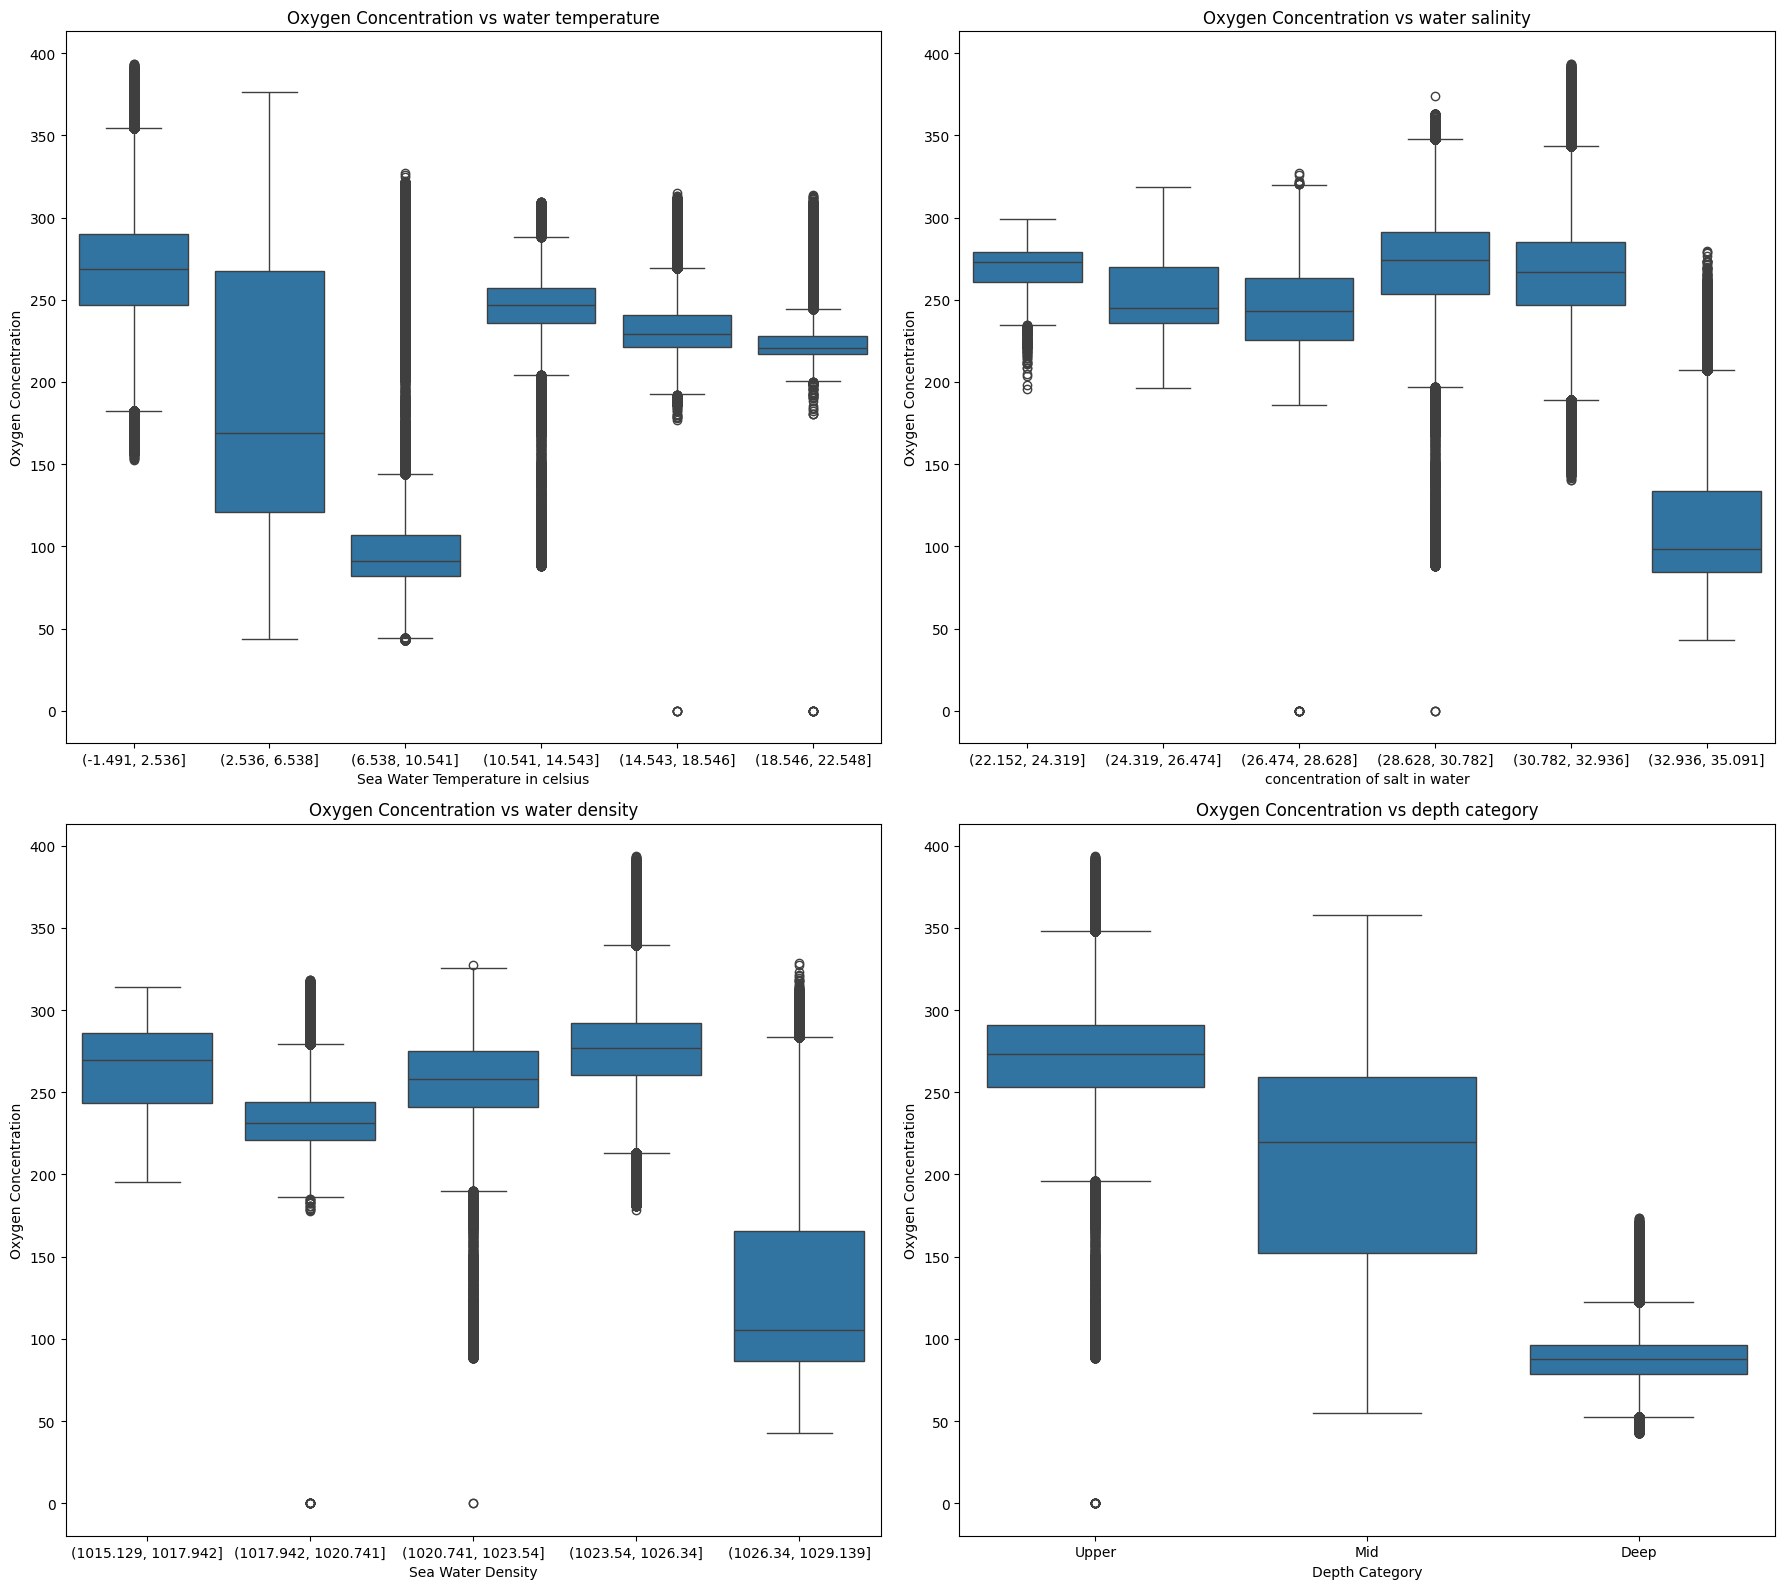

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 4 subplots (2 rows, 2 columns)

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# First plot (top left)
sns.boxplot(
    x=pd.cut(Glider_df['sea_water_temperature'], bins=6),
    y='micromoles_of_oxygen_per_unit_mass_in_sea_water',
    data=Glider_df,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Oxygen Concentration vs water temperature')
axes[0, 0].set_xlabel('Sea Water Temperature in celsius')
axes[0, 0].set_ylabel('Oxygen Concentration')

# Second plot (top right)
sns.boxplot(
    x=pd.cut(Glider_df['sea_water_practical_salinity'], bins=6),
    y='micromoles_of_oxygen_per_unit_mass_in_sea_water',
    data=Glider_df,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Oxygen Concentration vs water salinity')
axes[0, 1].set_xlabel('concentration of salt in water')
axes[0, 1].set_ylabel('Oxygen Concentration')

# Third plot (bottom left)
sns.boxplot(
    x=pd.cut(Glider_df['sea_water_density'], bins=5),
    y='micromoles_of_oxygen_per_unit_mass_in_sea_water',
    data=Glider_df,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Oxygen Concentration vs water density')
axes[1, 0].set_xlabel('Sea Water Density')
axes[1, 0].set_ylabel('Oxygen Concentration')

# Fourth plot (bottom right)
sns.boxplot(
    x='depth_category',
    y='micromoles_of_oxygen_per_unit_mass_in_sea_water',
    data=Glider_df,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Oxygen Concentration vs depth category')
axes[1, 1].set_xlabel('Depth Category')
axes[1, 1].set_ylabel('Oxygen Concentration')

plt.tight_layout()
plt.show()

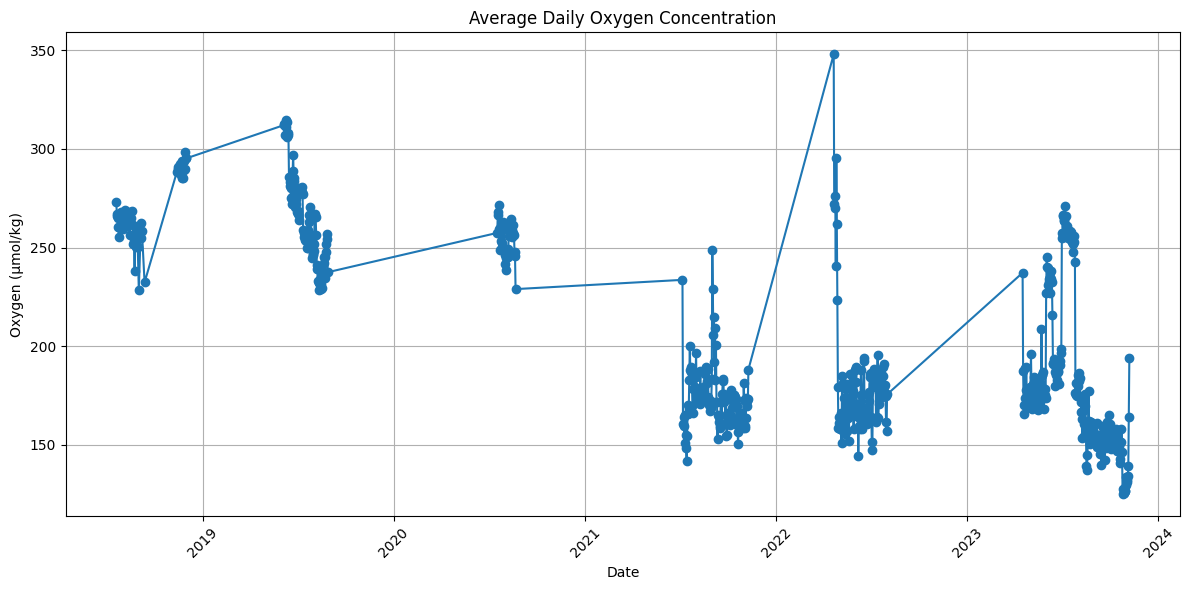

In [21]:
Glider_df['date'] = pd.to_datetime(Glider_df['date'])

glider_avg = Glider_df.groupby(Glider_df['date'].dt.date)['micromoles_of_oxygen_per_unit_mass_in_sea_water'].mean()
plt.figure(figsize=(12,6))
plt.plot(glider_avg.index, glider_avg.values, marker='o', linestyle='-')
plt.title('Average Daily Oxygen Concentration')
plt.xlabel('Date')
plt.ylabel('Oxygen (µmol/kg)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
# Oxygen concentration seems to decrease from spring to fall. There is a decreasing trend from 2018 to 2024. During summer of 2024, we witnessed the oxygen concentration rocketed. This can be efected by the increase of temperature and decrease off salinity as the plot below.

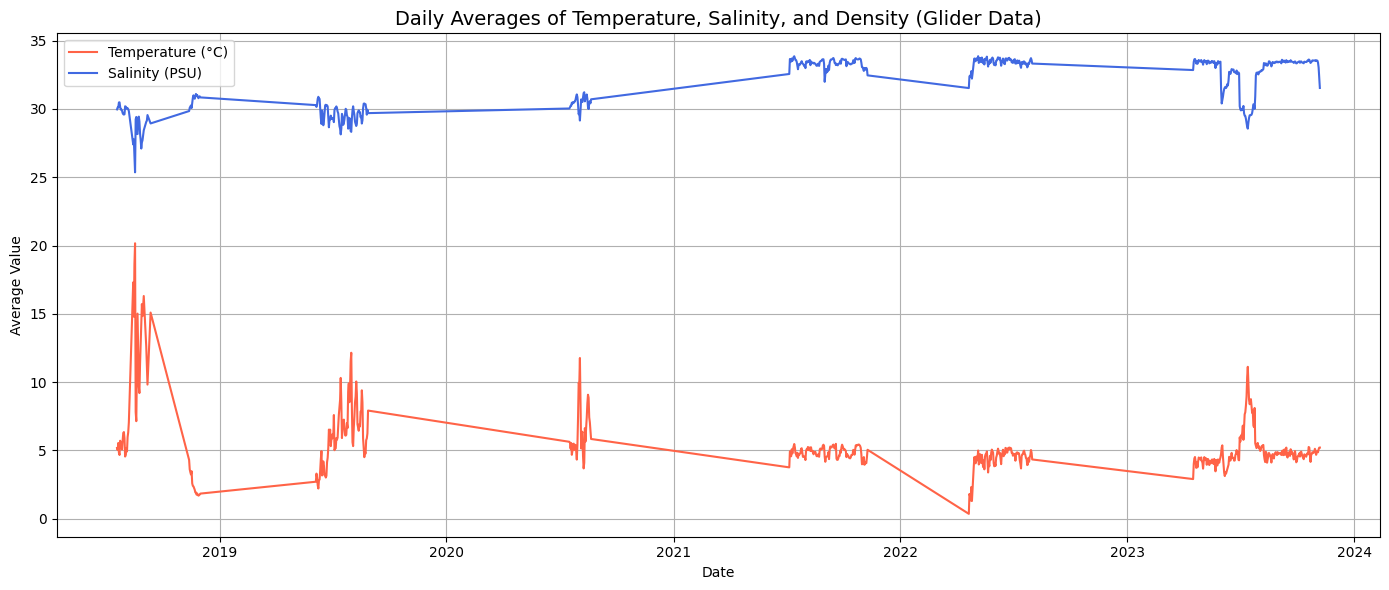

In [22]:
Glider_df['time'] = pd.to_datetime(Glider_df['time'])

# Group by day and compute average values
daily_avg = Glider_df.groupby(Glider_df['time'].dt.date)[
    ['sea_water_temperature', 'sea_water_practical_salinity', 'sea_water_density']
].mean().reset_index()

# Convert date back to datetime for plotting
daily_avg['time'] = pd.to_datetime(daily_avg['time'])

# Plot
plt.figure(figsize=(14, 6))

plt.plot(daily_avg['time'], daily_avg['sea_water_temperature'], color='tomato', label='Temperature (°C)')
plt.plot(daily_avg['time'], daily_avg['sea_water_practical_salinity'], color='royalblue', label='Salinity (PSU)')
#plt.plot(daily_avg['time'], daily_avg['sea_water_density'], color='seagreen', label='Density (kg/m³)')

plt.title('Daily Averages of Temperature, Salinity, and Density (Glider Data)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


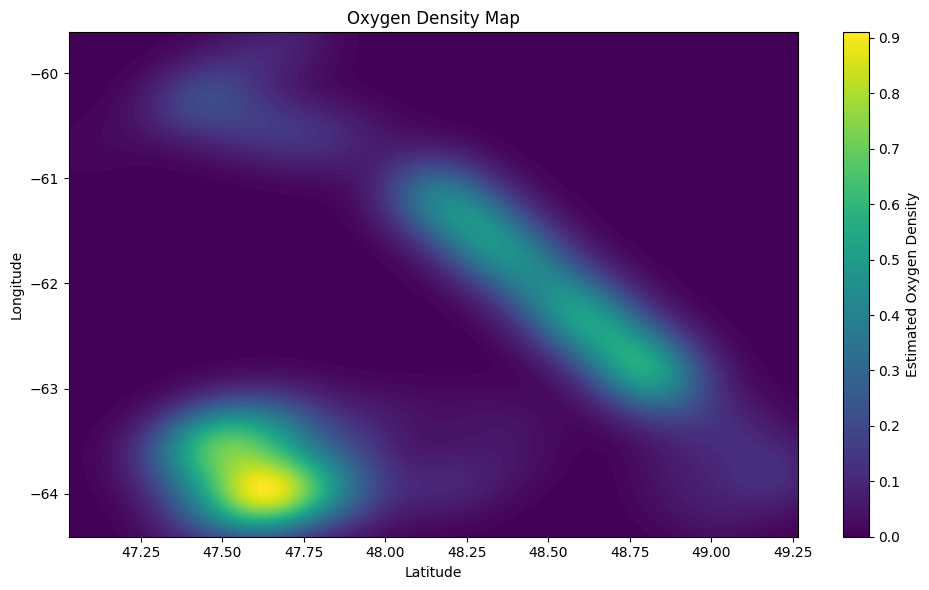

In [49]:
from scipy.stats import gaussian_kde
df = Glider_sampled_df.dropna(subset=["latitude", "longitude", "oxygen_concentration"])
x = df["latitude"]
y = df["longitude"]
z = df["oxygen_concentration"]

# Weighted KDE
xy = np.vstack([x, y])
kde = gaussian_kde(xy, weights=z)
xi, yi = np.mgrid[x.min():x.max():100j, y.min():y.max():100j]
zi = kde(np.vstack([xi.ravel(), yi.ravel()]))

# Plot it
plt.figure(figsize=(10, 6))
plt.contourf(xi, yi, zi.reshape(xi.shape), levels=100, cmap="viridis")
plt.colorbar(label="Estimated Oxygen Density")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Oxygen Density Map")
plt.tight_layout()
plt.show()

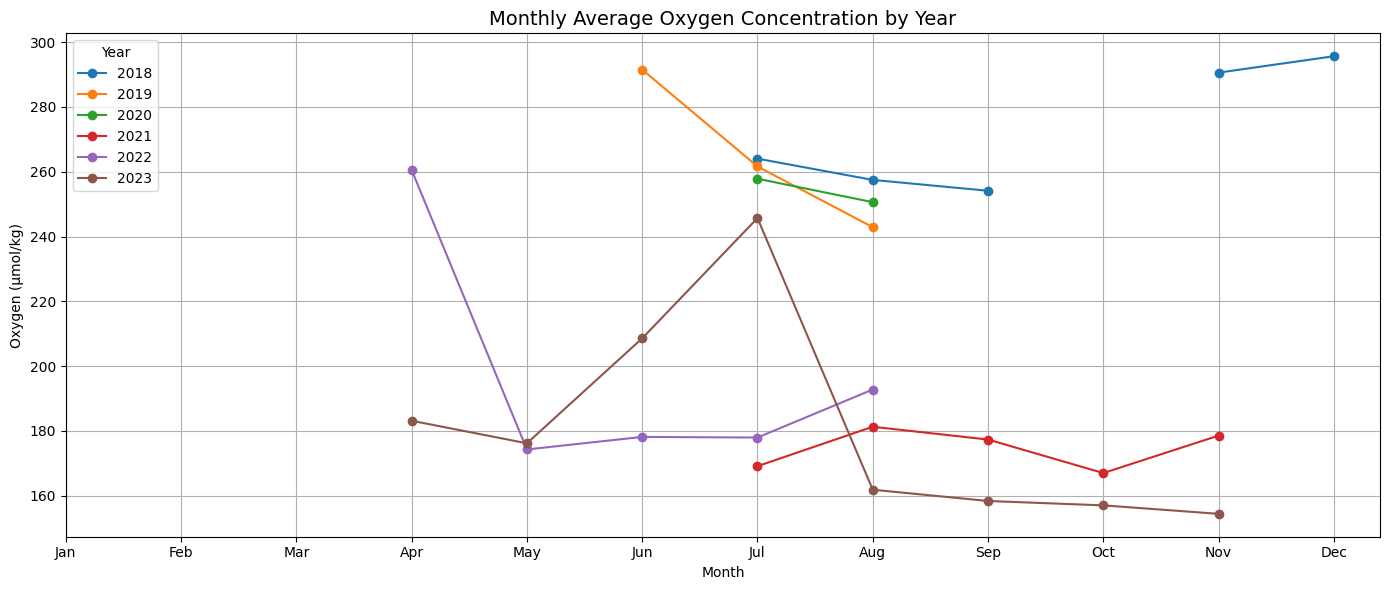

In [23]:
Glider_sampled_df['time'] = pd.to_datetime(Glider_sampled_df['time'])
Glider_sampled_df['month'] = Glider_sampled_df['time'].dt.month
Glider_sampled_df['year'] = Glider_sampled_df['time'].dt.year

# Group by year and month to get the average oxygen
monthly_avg = Glider_sampled_df.groupby(['year', 'month'])['micromoles_of_oxygen_per_unit_mass_in_sea_water'].mean().reset_index()

# Pivot the data for plotting
pivot = monthly_avg.pivot(index='month', columns='year', values='micromoles_of_oxygen_per_unit_mass_in_sea_water')

# Plot
plt.figure(figsize=(14, 6))

for year in pivot.columns:
    plt.plot(pivot.index, pivot[year], marker='o', label=str(year))

plt.title('Monthly Average Oxygen Concentration by Year', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Oxygen (µmol/kg)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend(title='Year')
plt.tight_layout()
plt.show()


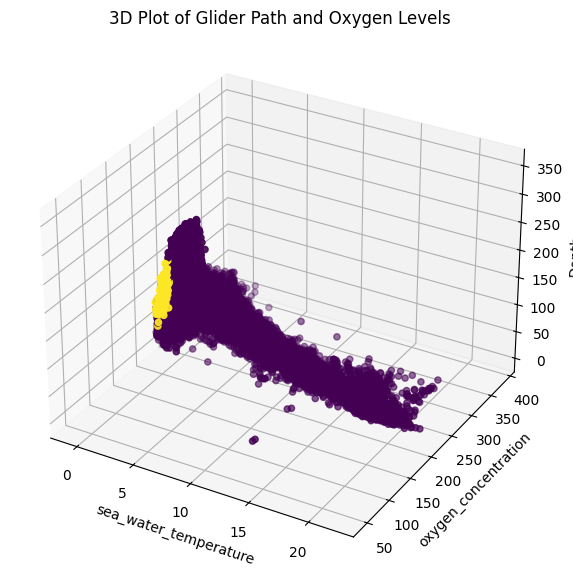

In [54]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(Glider_sampled_df['sea_water_temperature'], Glider_sampled_df['oxygen_concentration'], Glider_sampled_df['depth'],
           c=Glider_sampled_df['low_oxygen'], cmap='viridis', s=20)
ax.set_xlabel('sea_water_temperature')
ax.set_ylabel('oxygen_concentration')
ax.set_zlabel('Depth')
plt.title('3D Plot of Glider Path and Oxygen Levels')
plt.show()

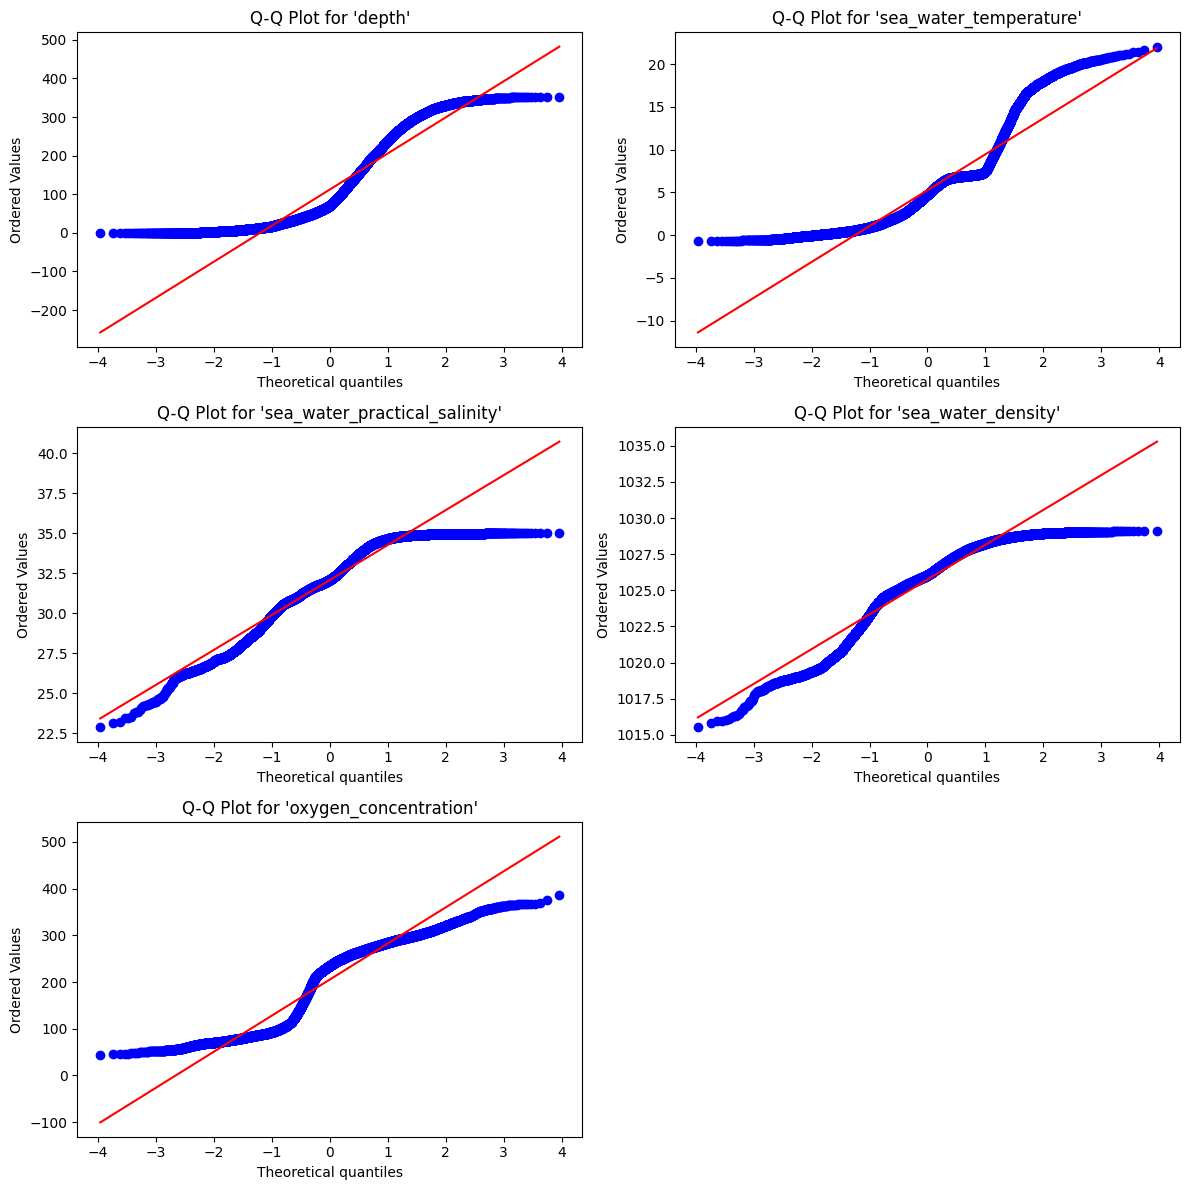

In [50]:

columns_to_plot = ['depth', 'sea_water_temperature', 'sea_water_practical_salinity','sea_water_density','oxygen_concentration']  # ← customize this list

# Create subplots
num_cols = len(columns_to_plot)
rows = (num_cols + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
axes = axes.flatten()

# Generate Q-Q plots
for i, col in enumerate(columns_to_plot):
    stats.probplot(Glider_sampled_df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q Plot for '{col}'")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Validation (KNN)


✅ Unique matched glider oxygen values: 76
count    503.000000
mean     227.025749
std       80.706236
min       83.632227
25%      127.046562
50%      267.206597
75%      294.959507
max      305.657792
Name: glider_oxygen, dtype: float64


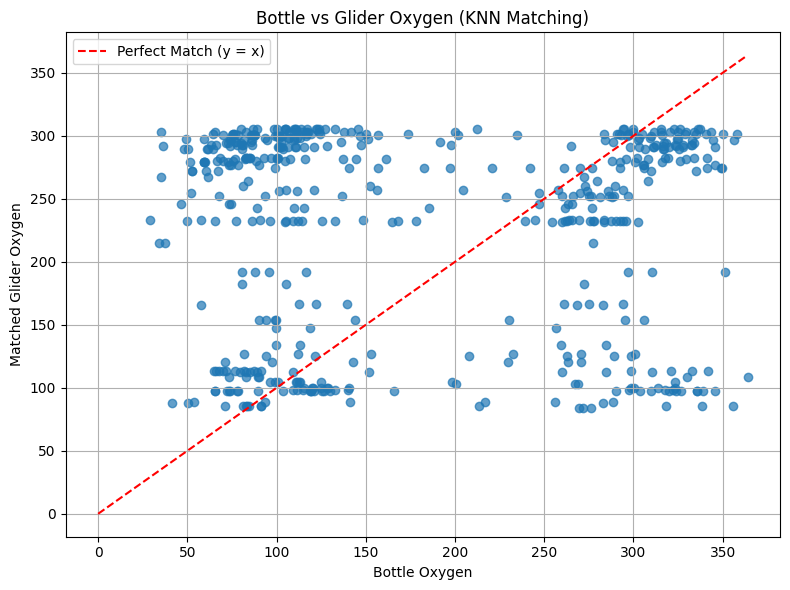

In [25]:
from sklearn.neighbors import NearestNeighbors


# --- Step 1: Convert timestamps ---
Glider_df['timestamp'] = pd.to_datetime(Glider_df['time'])
bottle_df['timestamp'] = pd.to_datetime(bottle_df['timestamp'], format="%Y-%m-%d %H:%M:%S")

# --- Step 2: Convert timestamps to numeric (seconds since glider start) ---
time_base = Glider_df['timestamp'].min()
Glider_df['timestamp_numeric'] = (Glider_df['timestamp'] - time_base) / np.timedelta64(1, 's')
bottle_df['timestamp_numeric'] = (bottle_df['timestamp'] - time_base) / np.timedelta64(1, 's')


# --- Step 3: Match column names ---
bottle_df = bottle_df.rename(columns={'Latitude': 'latitude', 'Longitude': 'longitude'})

# --- Step 4: Prepare features ---
glider_features = Glider_df[['latitude', 'longitude', 'timestamp_numeric']]
bottle_features = bottle_df[['latitude', 'longitude', 'timestamp_numeric']]

# --- Step 5: Fit KNN ---
knn = NearestNeighbors(n_neighbors=1, metric='euclidean')
knn.fit(glider_features)
distances, indices = knn.kneighbors(bottle_features)

# --- Step 6: Assign matched glider values ---
bottle_df['glider_oxygen'] = Glider_df.loc[indices.flatten(), 'micromoles_of_oxygen_per_unit_mass_in_sea_water'].values
bottle_df['distance_to_glider'] = distances.flatten()
bottle_df['oxygen_diff'] = bottle_df['best_Oxygen'] - bottle_df['glider_oxygen']

# --- Step 7: Confirm variation ---
print("\n✅ Unique matched glider oxygen values:", bottle_df['glider_oxygen'].nunique())
print(bottle_df['glider_oxygen'].describe())

# --- Step 8: Plot comparison ---
plt.figure(figsize=(8, 6))
plt.scatter(bottle_df['best_Oxygen'], bottle_df['glider_oxygen'], alpha=0.7)
plt.plot([0, bottle_df['best_Oxygen'].max()], [0, bottle_df['best_Oxygen'].max()],
         color='red', linestyle='--', label='Perfect Match (y = x)')
plt.xlabel("Bottle Oxygen")
plt.ylabel("Matched Glider Oxygen")
plt.title("Bottle vs Glider Oxygen (KNN Matching)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Models ##

### Logistic Regression (No threshold tuning, No bootstraping)

In [26]:
from sklearn.linear_model import LogisticRegression

# Preprocess the 'timestamp' column
bottle_df['timestamp'] = pd.to_datetime(bottle_df['timestamp'])
bottle_df['timestamp'] = (bottle_df['timestamp'] - bottle_df['timestamp'].min()) / np.timedelta64(1, 's')  # Time in seconds since the first timestamp

# Define the features (independent variables) and target (dependent variable)
X = bottle_df[['timestamp', 'latitude', 'longitude', 'zone_label']]  # Features
y = bottle_df['low_oxygen']  # Target (binary)

# One-hot encoding for 'zone' variable
X = pd.get_dummies(X, drop_first=True)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and fit the Logistic Regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# Make predictions
y_pred = logreg.predict(X_test_scaled)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9504950495049505
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        96
           1       0.00      0.00      0.00         5

    accuracy                           0.95       101
   macro avg       0.48      0.50      0.49       101
weighted avg       0.90      0.95      0.93       101



C:\Users\fadav\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\fadav\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\fadav\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

### Logistic Regression (Threshold tuning & bootstraping)

In [27]:
# Prepare date column as numeric
Glider_sampled_df['date'] = pd.to_datetime(Glider_sampled_df['date'])
Glider_sampled_df['date_numeric'] = (Glider_sampled_df['date'] - Glider_sampled_df['date'].min()) / np.timedelta64(1, 's')

# Define features and target
X = Glider_sampled_df[['date_numeric', 'latitude', 'longitude', 'zone_label', 'depth', 'depth_category']]
y = Glider_sampled_df['low_oxygen']

# One-hot encode categorical zone_label
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Bootstrapping setup
n_iterations = 100
coefficients = []
accuracies = []

# Run bootstrapped training
for i in range(n_iterations):
    # Bootstrap sampling with replacement
    X_boot, y_boot = resample(X_train_scaled, y_train, random_state=i)

    # Logistic regression with class_weight balanced
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_boot, y_boot)

    # Save coefficients and test accuracy
    coefficients.append(model.coef_[0])
    acc = model.score(X_test_scaled, y_test)
    accuracies.append(acc)

# Convert to NumPy arrays
coefficients = np.array(coefficients)
accuracies = np.array(accuracies)

# Print average accuracy across bootstraps
print(f"\nAverage accuracy over {n_iterations} bootstraps: {accuracies.mean():.4f}")

# Confidence intervals for coefficients
conf_int = np.percentile(coefficients, [2.5, 97.5], axis=0)
print("\n95% confidence intervals for each coefficient:\n")
for i, col in enumerate(X.columns):
    print(f"{col}: {conf_int[0][i]:.4f} to {conf_int[1][i]:.4f}")

# Predict probabilities using last trained model
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Set custom threshold
threshold = 0.99
y_pred_thresholded = (y_proba >= threshold).astype(int)

# Evaluate with custom threshold
print(f"\nClassification Report using threshold = {threshold}:\n")
print(classification_report(y_test, y_pred_thresholded))



Average accuracy over 100 bootstraps: 0.9575

95% confidence intervals for each coefficient:

date_numeric: 2.5130 to 4.0081
latitude: -3.2498 to 1.5819
longitude: -8.5431 to -4.0691
depth: -1.7146 to -0.3732
zone_label_zone10: -0.0657 to 0.0184
zone_label_zone11: -0.1233 to -0.0288
zone_label_zone12: -0.0858 to 0.0004
zone_label_zone13: -0.0485 to 0.0073
zone_label_zone14: -0.1394 to -0.0475
zone_label_zone15: -0.5851 to -0.2140
zone_label_zone16: -0.4903 to -0.1669
zone_label_zone17: -0.0857 to -0.0273
zone_label_zone18: -0.4146 to 0.3732
zone_label_zone19: 0.0485 to 0.8564
zone_label_zone2: -0.8136 to -0.0190
zone_label_zone20: 0.4473 to 1.3553
zone_label_zone21: 0.4452 to 2.0654
zone_label_zone22: -0.7526 to 1.4435
zone_label_zone23: -0.0545 to -0.0111
zone_label_zone24: -0.2968 to 0.5077
zone_label_zone25: -0.6572 to 1.0688
zone_label_zone26: -0.0952 to 0.6406
zone_label_zone3: -0.4822 to 0.0294
zone_label_zone4: -0.0023 to 0.0603
zone_label_zone5: -0.0891 to 0.0105
zone_label_zo

### Random Forest ###

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Convert date to numeric (for consistency)
Glider_sampled_df['date'] = pd.to_datetime(Glider_sampled_df['date'])
Glider_sampled_df['date_numeric'] = (Glider_sampled_df['date'] - Glider_sampled_df['date'].min()) / np.timedelta64(1, 's')

# Define features and target
X = Glider_sampled_df[['date_numeric', 'latitude', 'longitude', 'zone_label', 'depth', 'depth_category', 'sea_water_practical_salinity', 'sea_water_density']]
y = Glider_sampled_df['low_oxygen']

# One-hot encode zone_label
X = pd.get_dummies(X, drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Random Forest with class_weight balanced
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9978302142663412
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3667
           1       0.88      0.70      0.78        20

    accuracy                           1.00      3687
   macro avg       0.94      0.85      0.89      3687
weighted avg       1.00      1.00      1.00      3687



# Linear Regression, Graphical Analysis of Variables

In [29]:
Glider_sampled_df.rename(columns = {'micromoles_of_oxygen_per_unit_mass_in_sea_water': 'oxygen_concentration'},inplace=True)
Glider_sampled_df = Glider_sampled_df.sort_values(by='time').reset_index(drop=True)


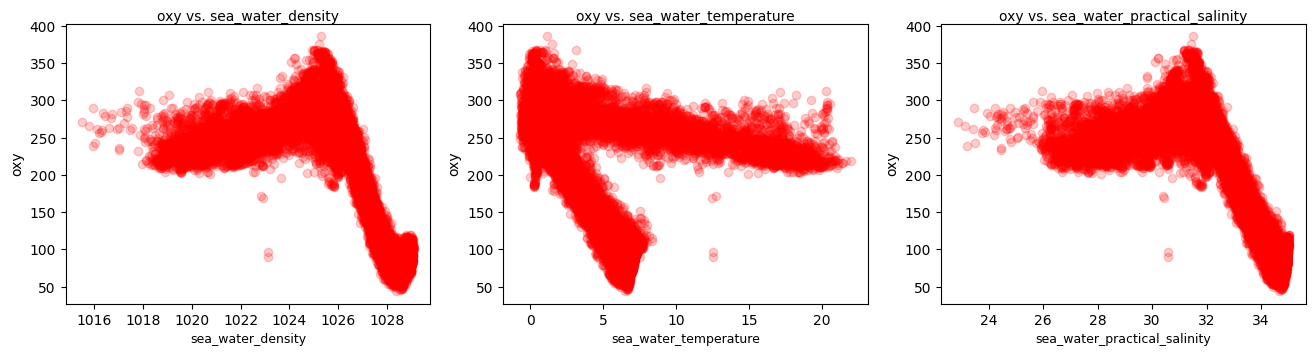

In [30]:
import numpy as np #Scatterplot of some important variables
varstolook = ['sea_water_density', 'sea_water_temperature', 'sea_water_practical_salinity'] #Sea water denisty and salinity seem to be very correlated
plt.figure(figsize=(16, 8))
for i,feature in enumerate(varstolook):
    plt.subplot(2,3,i+1) 
    colvalues = Glider_sampled_df[feature]
    plt.scatter(colvalues.values, Glider_sampled_df.oxygen_concentration.values, alpha=0.20, edgecolor=None, color='red') #oxy vs sea_water_temperature is odd (5 degrees)
    plt.xlabel(feature, fontsize = 9)
    plt.ylabel('oxy')
    plt.title("oxy vs. " + feature, fontsize=10, verticalalignment='top');

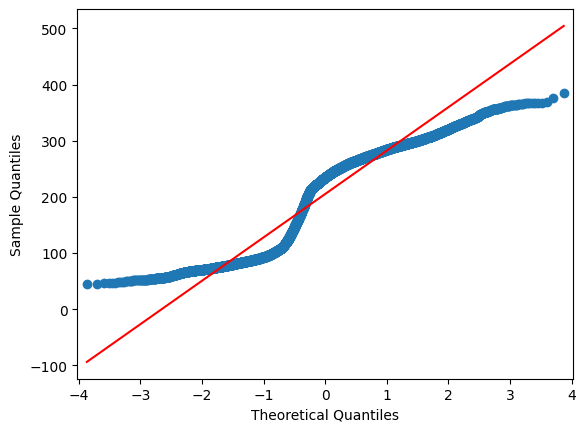

In [31]:
import statsmodels.api as sm
fig = sm.qqplot(Glider_sampled_df['oxygen_concentration'], line='r') #oxygen concentration shows heavy non-normality
plt.show()

In [32]:
Glider_sampled_df['year_month'] = Glider_sampled_df['time'].dt.to_period('M') 
monthly_df = Glider_sampled_df.groupby('year_month').agg({
    'oxygen_concentration': ['mean', 'std']
}).reset_index()

monthly_df.columns = ['year_month', 'oxygen_mean', 'oxygen_std']
monthly_df['month'] = monthly_df['year_month'].dt.month
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = monthly_df[['oxygen_mean', 'oxygen_std', 'month']]
scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
monthly_df['cluster'] = kmeans.fit_predict(scaled)

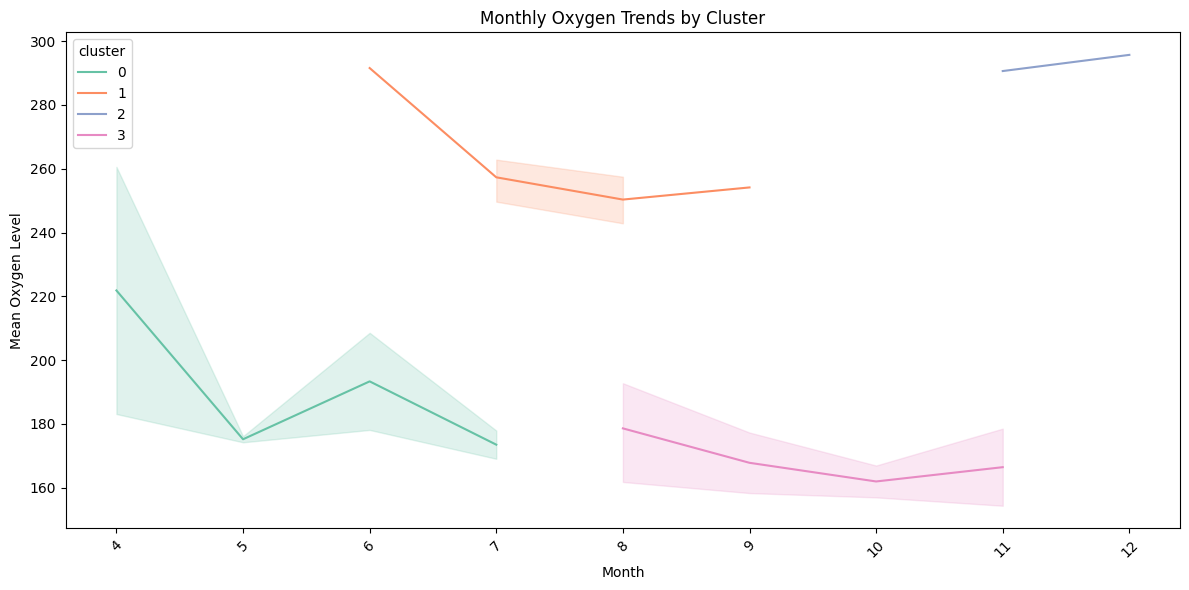

In [33]:
# Clustered average oxygen level over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='oxygen_mean', hue='cluster', data=monthly_df, palette='Set2')
plt.title('Monthly Oxygen Trends by Cluster')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Mean Oxygen Level')
plt.tight_layout()
plt.show()


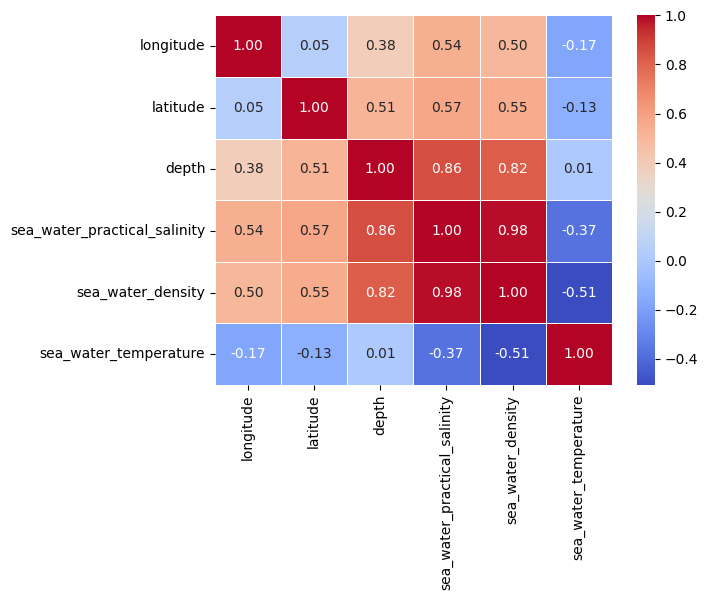

In [34]:
Glider_2 = Glider_sampled_df.copy()
corr_matrix = Glider_2[['longitude', 'latitude', 'depth', 'sea_water_practical_salinity', 'sea_water_density', 'sea_water_temperature']].corr() #Heatmap shows heavy collinearity between the majority of variables
corr_matrix
sns.heatmap(corr_matrix, cmap = 'coolwarm',  annot=True, fmt=".2f", linewidths=0.7)
plt.show() # From this heatmap, we expect highly accurate linear model results

In [35]:
X = Glider_sampled_df[['latitude', 'longitude', 'sea_water_temperature', 'depth','sea_water_practical_salinity', 'sea_water_density']] # Feature columns
y = Glider_sampled_df[['oxygen_concentration']].values.ravel() # Target variable



X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_vali, y_train, y_vali = train_test_split(X_rest, y_rest, test_size=0.20, random_state=42)

training_mean = X_train.mean()
training_std =  X_train.std()

# Center data 
X_train = (X_train - training_mean) / training_std
X_vali= (X_vali- training_mean) / training_std
X_test = (X_test - training_mean) / training_std

model_linear = sm.OLS(y_train, sm.add_constant(X_train))
original_linear = model_linear.fit()
print(original_linear.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                 2.273e+04
Date:                Thu, 10 Apr 2025   Prob (F-statistic):               0.00
Time:                        15:08:05   Log-Likelihood:                -53719.
No. Observations:               11796   AIC:                         1.075e+05
Df Residuals:                   11789   BIC:                         1.075e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [36]:
X_test_const = sm.add_constant(X_test)

# Predict using the trained model
y_pred_test = original_linear.predict(X_test_const)

# Compute evaluation metrics
mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
rss = np.sum((y_test - y_pred_test) ** 2)
n = len(y_test)
k = X_test.shape[1] + 1 # features + intercept

aic = n * np.log(rss / n) + 2 * k

print(f"Test MSE: {mse:.4f}")
print(f"Test R-squared: {r2:.4f}")
print(f"aic: {aic:.4f}")

Test MSE: 538.4873
Test R-squared: 0.9188
aic: 23200.6723


# Ridge Regression tuning

In [42]:
from sklearn.model_selection import KFold


lambdas = np.arange(0.1, 100.0, 0.1)
kf=KFold(n_splits=5,random_state=42,shuffle=True)
MSE_total=[]
R2_total = []
AIC_total = []
for index_train, index_test in kf.split(X_rest):
    
    #Extract folds
    X_train_fold, y_train_fold=X_rest.iloc[index_train], y_rest[index_train]
    X_test_fold, y_test_fold=X_rest.iloc[index_test], y_rest[index_test]
    
    #Normalize
    training_fold_mean = X_train_fold.mean()
    training_fold_std =  X_train_fold.std()
    X_train_fold = (X_train_fold - training_fold_mean) / training_fold_std 
    X_test_fold = (X_test_fold - training_fold_mean) / training_fold_std 
   
    MSE_fold=[]
    R2_fold = []  
    AIC_fold = []

    for l in lambdas:
        ridge = linear_model.Ridge(alpha=l, fit_intercept=True)
        ridge.fit(X_train_fold, y_train_fold)
        
        y_pred = ridge.predict(X_test_fold)
        
        rss = np.sum((y_test_fold - y_pred) ** 2)
        n = len(y_test_fold)
        k = X_test_const.shape[1]  # features + intercept

        aic = n * np.log(rss / n) + 2 * k
        
        #Compute the MSE,R2, AIC for the test data
        MSE_fold.append(mean_squared_error(y_test_fold, ridge.predict(X_test_fold)))
        R2_fold.append(r2_score(y_test_fold, ridge.predict(X_test_fold)))
        AIC_fold.append(aic)
    
    MSE_total.append(MSE_fold)
    R2_total.append(R2_fold)
    AIC_total.append(AIC_fold)

Text(0.5, 1.0, 'Mean MSE curve')

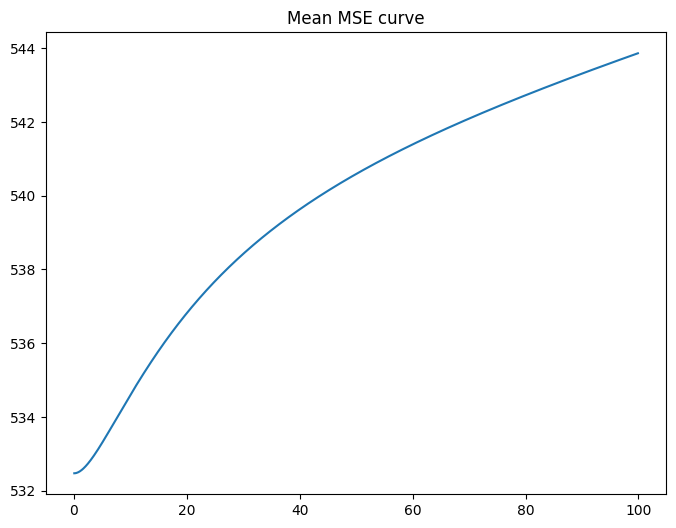

In [43]:
#Finding best lambda occurs through visual analysis
MSE_lambdas=np.matrix(MSE_total).mean(0).reshape(len(lambdas),1)
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(lambdas, MSE_lambdas)
ax.set_title('Mean MSE curve')

In [44]:

# Convert to numpy arrays
MSE_total = np.array(MSE_total)
R2_total = np.array(R2_total)
AIC_total = np.array(AIC_total)

# Average across folds (axis=0)
mean_r2 = R2_total.mean(axis=0)
mean_mse = MSE_total.mean(axis=0)
mean_aic = AIC_total.mean(axis=0)

# best lambda by mse, and its other metrics
best_index = np.argmin(mean_mse)
best_lambda_mse = lambdas[best_index]

print(f"Best lambda by Average MSE: {best_lambda_mse:.2f} (MSE = {mean_mse[best_index]:.4f}) (R² = {mean_r2[best_index]:.4f}) (AIC = {mean_aic[best_index]:.4f})")



Best lambda by Average MSE: 0.10 (MSE = 532.4732) (R² = 0.9200) (AIC = 18525.7784)


## Residual Plots

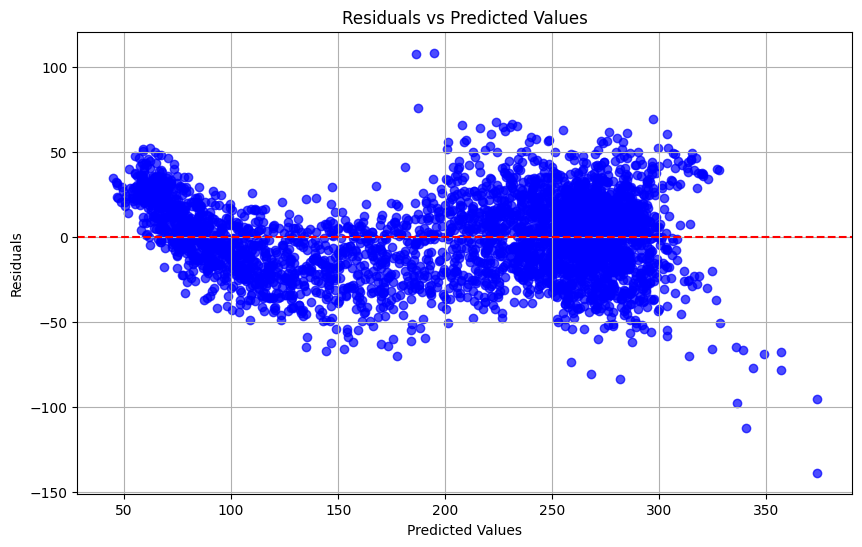

In [45]:
from sklearn.linear_model import Ridge

ridge_final = Ridge(alpha=best_lambda_mse)
ridge_final.fit(X_train, y_train)

# Predict on test set
y_pred = ridge_final.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='blue', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.grid(True)
plt.show()

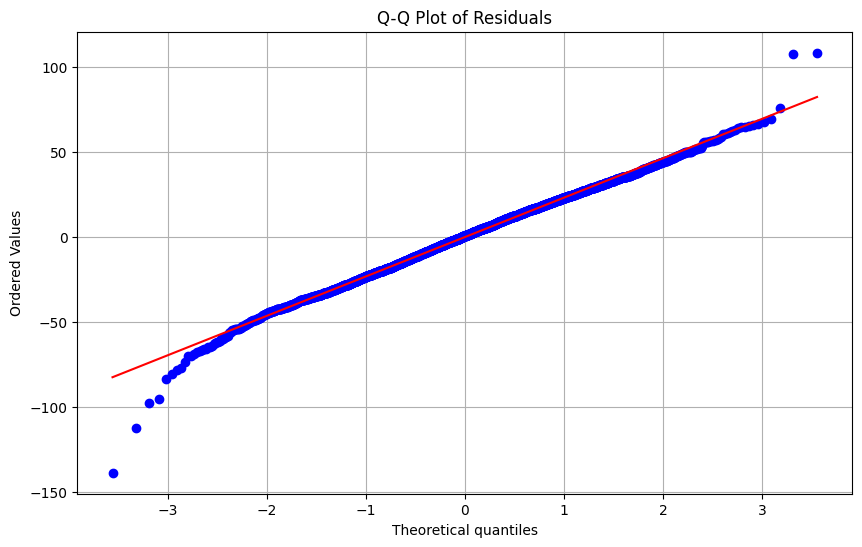

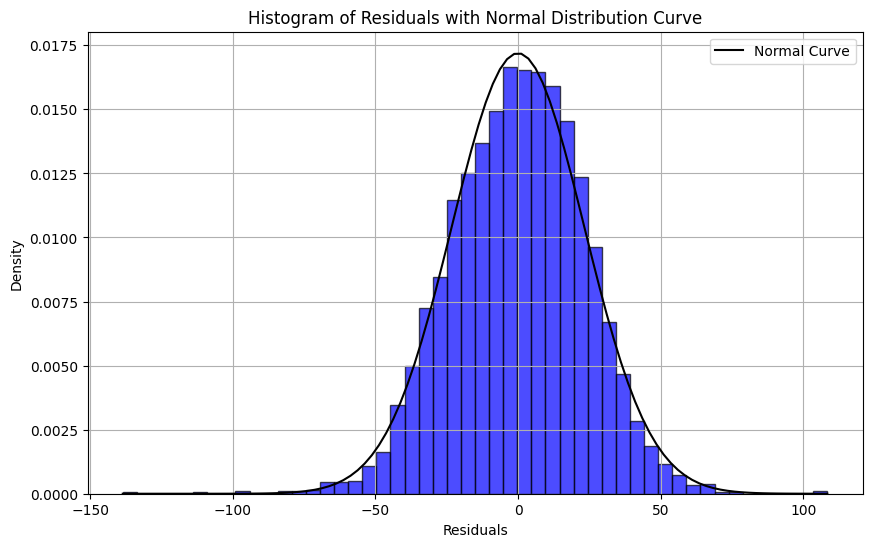

In [46]:
import scipy.stats as stats

# Q-Q plot to check normality
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True)
plt.show()

# Histogram of residuals 
plt.figure(figsize=(10, 6))
# Plot histogram
plt.hist(residuals, bins=50, color='blue', edgecolor='black', alpha=0.7, density=True)

# Add normal distribution curve
from scipy.stats import norm
normal_dist = np.linspace(residuals.min(), residuals.max(), 100)

mean=residuals.mean()
std = residuals.std()

plt.plot(normal_dist, norm.pdf(normal_dist, mean, std), 'k', label="Normal Curve") #normal curve

plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Histogram of Residuals with Normal Distribution Curve')
plt.grid(True)
plt.legend()
plt.show()


## Bottle Data Regression

In [52]:
bottle_df['date'] = pd.to_datetime(bottle_df['date'])
bottle_df['month'] = bottle_df['date'].dt.month
bottle_df['year'] = bottle_df['date'].dt.year

# Assuming bottle_df is the DataFrame and target is 'low_oxygen'
X = bottle_df[['latitude', 'longitude', 'month']]  # Features
y = bottle_df['best_Oxygen']  # Target

# Fit the logistic regression model
bottle_linear = sm.OLS(y, X).fit()

# Print the summary of the logistic regression model
print(bottle_linear.summary())

                                 OLS Regression Results                                
Dep. Variable:            best_Oxygen   R-squared (uncentered):                   0.764
Model:                            OLS   Adj. R-squared (uncentered):              0.762
Method:                 Least Squares   F-statistic:                              539.0
Date:                Thu, 10 Apr 2025   Prob (F-statistic):                   3.16e-156
Time:                        16:48:17   Log-Likelihood:                         -3034.1
No. Observations:                 503   AIC:                                      6074.
Df Residuals:                     500   BIC:                                      6087.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------